# Regressione lineare semplice

In [29]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [5]:
class LinearRegression:
    #questa classe avrà 2 attibuti: uno per il peso, uno per il bias
    coef_ = None
    intercept_ = None
    
    # definiamo un metodo per l'addestramento del modello:
    
    def fit(self, x, y): # prende input, feature e target
        # dobbiamo calcolare per prima cosa il metodo dei minimi quadrati
        
        x_sum = x.sum()
        y_sum = y.sum()
        xy_sum = (x*y).sum()
        x2_sum = (x*x).sum()
        n = y.shape[0]
        
        self.coef_ = (n * xy_sum - x_sum * y_sum) / (n * x2_sum - x_sum * x_sum)
        self.intercept_ = (y_sum - self.coef_ * x_sum) / n
        
    # per la previsione sui nuovi dati
    def predict(self, x):
        return self.coef_ * x + self.intercept_

In [6]:
# proviamo a stimare il valore di monolocali a milano

x_train = np.array([[80, 150, 30, 50, 120, 60, 110, 110]])
y_train = np.array([16, 30, 12, 10, 24, 18, 20, 25])

# usiamo una scala di 10.000 euro per il valore
lr = LinearRegression() # andiamo a istanziare la classe
lr.fit(x_train, y_train) # usiamo il metodo fit

In [7]:
# se vogliamo ottenere una stima di un nuovo monolocale, ci basta usare il metodo predict

lr.predict(70)

np.float64(16.447225244831337)

L'appartamento di 70 m2 si stima che sosterà **1.644.000 euro**

### Generazione grafico

In [1]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

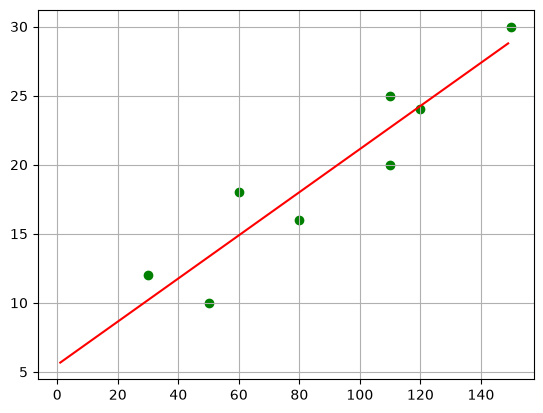

In [14]:
plt.scatter(x_train, y_train, c="green")
x_line = np.arange(1, 150)
y_line = lr.predict(x_line)
plt.plot(x_line, y_line, c="red")
plt.grid()
plt.show

# Metriche

In [15]:
def mean_absolute_error(y_true, y_pred):
    return np.abs(y_true-y_pred).sum()/y_true.shape[0]

def mean_squared_error(y_true, y_pred):
    return np.power(y_true, y_pred, 2).sum()/y_true.shape[0]

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def _rss(y_true, y_pred):
    return np.power(y_true-y_pred, 2).sum()

def _sst(y_true, y_pred):
    return np.power(y_true-y_pred.mean(), 2).sum()

def r2_score(y_true, y_pred):
    return 1-_rss(y_true, y_pred)/_sst(y_true, y_pred)


In [16]:
x_train = np.array([[80, 150, 30, 50, 120, 60, 110, 110]])
y_train = np.array([16, 30, 12, 10, 24, 18, 20, 25])

lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)
print(y_pred)

[[18.00870511 28.9390642  10.20130577 13.32426551 24.25462459 14.88574538
  22.69314472 22.69314472]]
